<a href="https://colab.research.google.com/github/shauryasachdev/Vizuara_CV/blob/main/ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
# import required libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [133]:
# transformation of PIL data into tensor format
transform_operation = transforms.Compose([transforms.ToTensor()])

In [134]:
# getting PIL data and transforming it into tensors
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform = transform_operation)
train_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform = transform_operation)

In [135]:
# define variables
batch_size = 64
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
patch_num = (img_size // patch_size) * (img_size // patch_size)
attention_heads = 4
embed_dim = 16
transformer_blocks = 4
mlp_nodes = 64
learning_rate = 0.001
epochs = 5

In [136]:
# using dataloader to prepare data for nueral network
train_data = dataloader.DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
val_data = dataloader.DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

In [137]:
# Class for PatchEmbedding - Part 1 of the ViT architecture

class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride = patch_size)

  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x

In [138]:
# Class for Transformer Encoder - Part 2 of the ViT architecture

# Layer Normalization
# MultiHead Attention
# Layer Normalization
# Residuals
# MLP with Activation Function

class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embed_dim)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_heads, batch_first = True)
    self.layer_norm2 = nn.LayerNorm(embed_dim)
    self.mlp = nn.Sequential(
        nn.Linear(embed_dim, mlp_nodes),
        nn.GELU(),
        nn.Linear(mlp_nodes, embed_dim)
    )

  def forward(self, x):
    residual_1 = x
    x = self.layer_norm1(x)
    x = self.multi_head_attention(x, x, x)[0] + residual_1
    residual_2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)+residual_2
    return x

In [139]:
# Class for MLP head classification - Part 3 of the ViT architecture

class MLPHead(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernorm1 = nn.LayerNorm(embed_dim)
    self.mlphead = nn.Sequential(
        #nn.Linear(embed_dim)
        nn.Linear(embed_dim, num_classes)
    )

  def forward(self, x):
    #x = x[:,0]
    x= self.layernorm1(x)
    x = self.mlphead(x)
    return x


In [140]:
from torch.nn.modules.transformer import Transformer
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embedding = nn.Parameter(torch.rand(1, patch_num+1, embed_dim))
    self.transformer_blocks = nn.Sequential(* [TransformerEncoder() for _ in range (transformer_blocks)])
    self.mlp_head = MLPHead()

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.size(0)
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), 1)
    x = x + self.pos_embedding
    x = self.transformer_blocks(x)
    x = x[:,0]
    x = self.mlp_head(x)
    return x

In [141]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [144]:
from torch.nn.modules import loss

for epoch in range(epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"\nEpoch {epoch+1}")

  for batch_idx, (images, labels) in enumerate(train_data):
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    preds = outputs.argmax(dim=1)

    correct = (preds == labels).sum().item()
    accuracy = 100.0 * correct / labels.size(0)

    correct_epoch += correct
    total_epoch += labels.size(0)

    if batch_idx % 100 ==0:
      print(f"Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}:, Accuracy = {accuracy:.2f}%")

  epoch_acc = 100.0 * correct_epoch / total_epoch
  print(f"==> Epoch: {epoch+1} Training Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")

  # Validation loop
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
    for images_val, labels_val in val_data:
      images_val = images_val.to(device)
      labels_val = labels_val.to(device)

      outputs_val = model(images_val)
      preds_val = outputs_val.argmax(dim=1)

      correct_val += (preds_val == labels_val).sum().item()
      total_val += labels_val.size(0)

  val_accuracy = 100.0 * correct_val / total_val
  print(f"==> Epoch: {epoch+1} Validation Accuracy: {val_accuracy:.2f}%")


Epoch 1
Batch   1: Loss = 0.2154:, Accuracy = 95.31%
Batch 101: Loss = 0.2269:, Accuracy = 93.75%
==> Epoch: 1 Training Summary: Total Loss = 36.3045, Accuracy = 93.38%
==> Epoch: 1 Validation Accuracy: 94.78%

Epoch 2
Batch   1: Loss = 0.2098:, Accuracy = 93.75%
Batch 101: Loss = 0.1309:, Accuracy = 93.75%
==> Epoch: 2 Training Summary: Total Loss = 30.6018, Accuracy = 94.11%
==> Epoch: 2 Validation Accuracy: 95.79%

Epoch 3
Batch   1: Loss = 0.0468:, Accuracy = 100.00%
Batch 101: Loss = 0.1556:, Accuracy = 95.31%
==> Epoch: 3 Training Summary: Total Loss = 29.0607, Accuracy = 94.38%
==> Epoch: 3 Validation Accuracy: 95.90%

Epoch 4
Batch   1: Loss = 0.2548:, Accuracy = 89.06%
Batch 101: Loss = 0.1283:, Accuracy = 95.31%
==> Epoch: 4 Training Summary: Total Loss = 24.0022, Accuracy = 95.44%
==> Epoch: 4 Validation Accuracy: 96.17%

Epoch 5
Batch   1: Loss = 0.0750:, Accuracy = 98.44%
Batch 101: Loss = 0.0884:, Accuracy = 96.88%
==> Epoch: 5 Training Summary: Total Loss = 21.1963, Acc

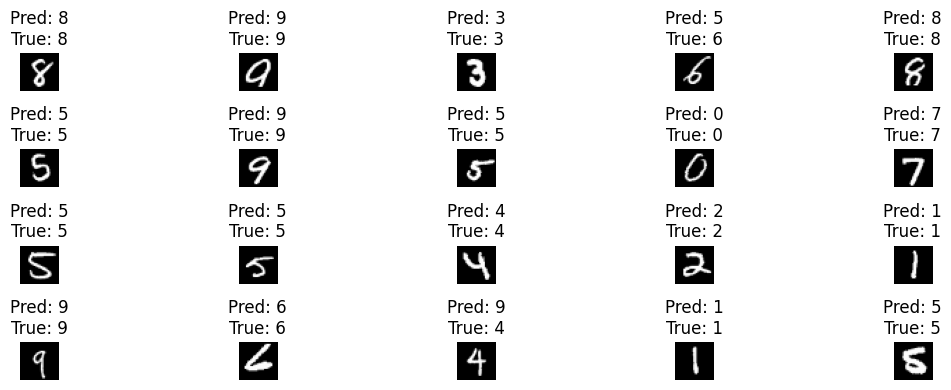

In [145]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()